# 02 — Model Training

Two-stage training pipeline for flow limitation (FL) classification.

## Stage 1 — Baseline: Logistic Regression (Mann et al. approach)
- Logistic regression trained on the full dataset using LOPO-CV for evaluation
- Mirrors the Mann et al. 2021 modelling philosophy: interpretable, linear, clinically translatable
- Final model retrained on **all** data and saved as the deployable baseline

## Stage 2 — Comparison: Tree-based models with LOPO-CV
- Random Forest, XGBoost, LightGBM evaluated under the same LOPO-CV protocol
- Compared against the LogReg baseline on Accuracy, F1, ROC-AUC, Cohen's Kappa
- Best-performing model also saved

## Design decisions
- **LOPO-CV** (Leave-One-Patient-Out) throughout — breath-level random splits leak patient identity and inflate performance
- **No hyperparameter tuning inside LOPO-CV** — to avoid data leakage through the CV loop; sensible defaults used
- **StandardScaler fit on train fold only**, applied to test fold — no look-ahead
- Input: `features_clean.csv` from notebook 01

## Feature set: 18 features (reduced from 25 based on notebook 01 validation)

Features removed following cohort-level Mann-Whitney U testing and correlation analysis on n=84 patients:

| Removed feature | Reason |
|---|---|
| `insp_cv` | Not significant across cohort (p=0.093) |
| `vol_ratio` | Not significant across cohort (p=0.190) |
| `flatness_insp_50` | Collinear with `insp_skew` (r=−0.943); `insp_skew` is stronger discriminator (p=2.6e-87 vs p=2.8e-49) |
| `auc_insp`, `auc_exp` | Collinear with `auc_total`; total used alone to avoid multicollinearity |

One new feature added:

| New feature | Meaning |
|---|---|
| `auc_total` | Total sum of normalized flow across both phases — amplitude-independent overall breath magnitude |

## Outputs
- `model_logreg_baseline.pkl` — fitted LogReg on full data (deploy this)
- `model_best.pkl` — best model from Stage 2 (if it beats LogReg)
- `scaler_logreg.pkl` — scaler fitted on full data (needed for inference)
- `lopo_cv_results.csv` — per-patient, per-model CV metrics
- `model_comparison.png` — summary figure

## 1. Setup & Imports

In [42]:
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    cohen_kappa_score, confusion_matrix,
    classification_report, RocCurveDisplay,
)
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

# ── Paths ─────────────────────────────────────────────────────────────────────
INPUT_CSV = Path('features_clean.csv')   # output of notebook 01
OUT_DIR   = Path('./models')                    # save models alongside notebooks

# ── Feature columns: 18 features ─────────────────────────────────────────────
# Reduced from 25 based on notebook 01 cohort-level validation (n=84 patients):
#   Removed insp_cv         — not significant across cohort (p=0.093)
#   Removed vol_ratio       — not significant across cohort (p=0.190)
#   Removed flatness_insp_50 — collinear with insp_skew (r=-0.943)
#   Removed auc_insp, auc_exp — collinear with auc_total; total used alone
# Added auc_total — new amplitude-independent feature (notebook 01)
FEATURE_NAMES = [
    # Scooping (Mann et al.)
    'quad_insp', 'quad_insp_50', 'quad_exp', 'area_under_peaks_insp',
    # Flutter (Mann et al.)
    'power_5to12_insp', 'power_5to12_exp',
    # Flatness — 50% threshold dropped (collinear); 75% and 90% retained
    'flatness_insp_75', 'flatness_insp_90',
    # Asymmetry
    'insp_peak_position', 'pif_pef_ratio',
    # Phase timing
    'ie_ratio', 'insp_duty', 'breath_duration',
    # Shape variability — insp_cv dropped (NS), vol_ratio dropped (NS)
    'exp_cv', 'insp_skew', 'exp_skew', 'insp_kurt',
    # Area under normalised curves (amplitude-independent)
    'auc_total',
]

print(f'Input  : {INPUT_CSV}')
print(f'Out dir: {OUT_DIR}')
print(f'Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES}')

Input  : features_clean.csv
Out dir: models
Features (18): ['quad_insp', 'quad_insp_50', 'quad_exp', 'area_under_peaks_insp', 'power_5to12_insp', 'power_5to12_exp', 'flatness_insp_75', 'flatness_insp_90', 'insp_peak_position', 'pif_pef_ratio', 'ie_ratio', 'insp_duty', 'breath_duration', 'exp_cv', 'insp_skew', 'exp_skew', 'insp_kurt', 'auc_total']


## 2. Load & Validate Data

In [43]:
df = pd.read_csv(INPUT_CSV)

# ── Sanity checks ─────────────────────────────────────────────────────────────
assert 'participant' in df.columns, 'Missing participant column'
assert 'target'      in df.columns, 'Missing target column'
for fn in FEATURE_NAMES:
    assert fn in df.columns, f'Missing feature column: {fn}'

# Only FL / NFL
df = df[df['target'].isin([0, 1])].reset_index(drop=True)

# Drop any remaining NaNs in feature columns
before = len(df)
df = df.dropna(subset=FEATURE_NAMES).reset_index(drop=True)
if len(df) < before:
    print(f'Dropped {before - len(df)} rows with NaN features')

participants = df['participant'].unique()
n_patients   = len(participants)

print(f'Dataset loaded:')
print(f'  Total breaths : {len(df)}')
print(f'  FL  (target=1): {(df["target"]==1).sum()}')
print(f'  NFL (target=0): {(df["target"]==0).sum()}')
print(f'  Patients      : {n_patients}')
print(f'  Breaths/patient: {len(df)/n_patients:.1f} mean')

# Warn if any patient has both classes missing
for pid in participants:
    p_df = df[df['participant'] == pid]
    if p_df['target'].nunique() < 2:
        print(f'  ⚠  Patient {pid} has only one class — will be a trivial LOPO fold')

Dataset loaded:
  Total breaths : 6993
  FL  (target=1): 3627
  NFL (target=0): 3366
  Patients      : 84
  Breaths/patient: 83.2 mean


## 3. LOPO-CV Helper

Single reusable function used for every model. Scaler is fit on the training fold only.

In [44]:
def lopo_cv(df, feature_names, model_factory, model_name='model', scale=True):
    """
    Leave-One-Patient-Out cross-validation.

    Parameters
    ----------
    df            : DataFrame with 'participant', 'target', and feature columns
    feature_names : list of feature column names
    model_factory : callable with no args that returns a fresh, unfitted model
    model_name    : string label for reporting
    scale         : whether to apply StandardScaler (True for LR; optional for trees)

    Returns
    -------
    results_df    : per-patient metrics DataFrame
    all_trues     : list of ground-truth labels across all folds
    all_probas    : list of predicted probabilities across all folds
    """
    participants = df['participant'].unique()
    records      = []
    all_trues, all_probas, all_preds = [], [], []

    for i, test_pid in enumerate(participants):
        train_df = df[df['participant'] != test_pid]
        test_df  = df[df['participant'] == test_pid]

        X_train = train_df[feature_names].values
        y_train = train_df['target'].values
        X_test  = test_df[feature_names].values
        y_test  = test_df['target'].values

        if scale:
            sc      = StandardScaler()
            X_train = sc.fit_transform(X_train)
            X_test  = sc.transform(X_test)

        model = model_factory()
        model.fit(X_train, y_train)

        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        all_trues.extend(y_test.tolist())
        all_probas.extend(y_proba.tolist())
        all_preds.extend(y_pred.tolist())

        n_fl  = int(y_test.sum())
        n_nfl = int((y_test == 0).sum())

        # Guard: ROC-AUC undefined if test fold has only one class
        try:
            fold_auc = roc_auc_score(y_test, y_proba)
        except ValueError:
            fold_auc = np.nan

        records.append({
            'model'    : model_name,
            'patient'  : test_pid,
            'n_fl'     : n_fl,
            'n_nfl'    : n_nfl,
            'accuracy' : accuracy_score(y_test, y_pred),
            'f1'       : f1_score(y_test, y_pred, zero_division=0),
            'roc_auc'  : fold_auc,
            'kappa'    : cohen_kappa_score(y_test, y_pred),
        })

        if (i + 1) % 10 == 0 or (i + 1) == len(participants):
            print(f'  [{model_name}] fold {i+1}/{len(participants)} done')

    results_df = pd.DataFrame(records)
    return results_df, all_trues, all_probas, all_preds


def summarise_lopo(results_df, model_name):
    """Print mean ± std across LOPO folds for key metrics."""
    metrics = ['accuracy', 'f1', 'roc_auc', 'kappa']
    print(f'\n── {model_name} LOPO-CV Summary ──')
    for m in metrics:
        col = results_df[m].dropna()
        print(f'  {m:<12}: {col.mean():.4f} ± {col.std():.4f}')


print('LOPO-CV helper defined.')

LOPO-CV helper defined.


---
## Stage 1 — Baseline: Logistic Regression

L2-regularised logistic regression — same model class as Mann et al. 2021.
Regularisation strength C is fixed at 0.1 (conservative) to avoid overfitting on
the relatively small number of breaths per patient.
Evaluated with LOPO-CV; final model then retrained on the full dataset.

In [45]:
print('Running LogReg LOPO-CV...\n')

lr_factory = lambda: LogisticRegression(
    penalty='l2',
    C=0.1,                # conservative regularisation
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',  # handles any FL/NFL imbalance per fold
    random_state=42,
)

lr_results, lr_trues, lr_probas, lr_preds = lopo_cv(
    df, FEATURE_NAMES, lr_factory, model_name='LogReg', scale=True
)

summarise_lopo(lr_results, 'Logistic Regression (baseline)')

Running LogReg LOPO-CV...

  [LogReg] fold 10/84 done
  [LogReg] fold 20/84 done
  [LogReg] fold 30/84 done
  [LogReg] fold 40/84 done
  [LogReg] fold 50/84 done
  [LogReg] fold 60/84 done
  [LogReg] fold 70/84 done
  [LogReg] fold 80/84 done
  [LogReg] fold 84/84 done

── Logistic Regression (baseline) LOPO-CV Summary ──
  accuracy    : 0.7602 ± 0.1294
  f1          : 0.7434 ± 0.1618
  roc_auc     : 0.8863 ± 0.0876
  kappa       : 0.5033 ± 0.2119


In [46]:
# ── Per-patient performance table ────────────────────────────────────────────
print('LogReg per-patient LOPO results:')
print(lr_results[['patient','n_fl','n_nfl','accuracy','f1','roc_auc','kappa']]
      .sort_values('roc_auc', ascending=False)
      .to_string(index=False))

# ── Aggregate confusion matrix across all folds ───────────────────────────────
cm_lr = confusion_matrix(lr_trues, lr_preds)
print(f'\nAggregate confusion matrix (all LOPO folds):')
print(f'                 Pred NFL   Pred FL')
print(f'  Actual NFL  :  {cm_lr[0,0]:>6}     {cm_lr[0,1]:>6}')
print(f'  Actual FL   :  {cm_lr[1,0]:>6}     {cm_lr[1,1]:>6}')

print(f'\nFull classification report:')
print(classification_report(lr_trues, lr_preds, target_names=['NFL','FL']))

LogReg per-patient LOPO results:
        patient  n_fl  n_nfl  accuracy       f1  roc_auc    kappa
     CM_2021-02    15      9  0.916667 0.928571 1.000000 0.829787
     TH_2021-06    21      7  0.571429 0.600000 1.000000 0.272727
     TC_2021-07     7     14  1.000000 1.000000 1.000000 1.000000
     SM_2021-11    14     17  0.935484 0.933333 1.000000 0.871369
    M38_2021-03    12     10  0.954545 0.956522 1.000000 0.909091
     CB_2021-08    22     13  0.857143 0.871795 0.996503 0.716370
     PR_2023-12    48     30  0.923077 0.934783 0.990972 0.841463
     DD_2024-03    22     41  0.873016 0.777778 0.986696 0.694915
     JM_2023-01    35      3  0.736842 0.833333 0.980952 0.283019
     ID_2021-11     9     10  0.578947 0.692308 0.977778 0.191489
     CD_2023-01    27      5  0.937500 0.962963 0.977778 0.762963
     CJ_2025-02    68    132  0.905000 0.840336 0.970588 0.774668
     MH_2023-06    58     49  0.813084 0.803922 0.969388 0.631670
     JW_2023-05    19     43  0.903226 0.83

In [47]:
# ── Train final LogReg on ALL data — this is the deployable baseline ──────────
print('Training final LogReg on full dataset...')

X_all = df[FEATURE_NAMES].values
y_all = df['target'].values

scaler_lr = StandardScaler()
X_all_scaled = scaler_lr.fit_transform(X_all)

final_lr = LogisticRegression(
    penalty='l2', C=0.1, solver='lbfgs',
    max_iter=1000, class_weight='balanced', random_state=42,
)
final_lr.fit(X_all_scaled, y_all)

# Save
joblib.dump(final_lr,   OUT_DIR / 'model_logreg_baseline.pkl')
joblib.dump(scaler_lr,  OUT_DIR / 'scaler_logreg.pkl')
print('Saved: model_logreg_baseline.pkl')
print('Saved: scaler_logreg.pkl')

# ── Coefficients: which features drive the model ──────────────────────────────
coef_df = pd.DataFrame({
    'feature'    : FEATURE_NAMES,
    'coefficient': final_lr.coef_[0],
}).sort_values('coefficient', key=abs, ascending=False)

print('\nLogReg coefficients (FL positive = pushes toward FL):')
print(coef_df.to_string(index=False))

Training final LogReg on full dataset...
Saved: model_logreg_baseline.pkl
Saved: scaler_logreg.pkl

LogReg coefficients (FL positive = pushes toward FL):
              feature  coefficient
            auc_total     0.826487
            insp_kurt     0.642240
      power_5to12_exp     0.529144
     power_5to12_insp     0.431341
      breath_duration    -0.416848
            quad_insp     0.414147
            insp_skew     0.379098
     flatness_insp_75    -0.355614
area_under_peaks_insp     0.298415
               exp_cv    -0.177773
             exp_skew     0.161473
             ie_ratio     0.148362
            insp_duty    -0.081663
   insp_peak_position    -0.077179
        pif_pef_ratio    -0.065149
         quad_insp_50     0.060585
             quad_exp     0.037167
     flatness_insp_90    -0.032538


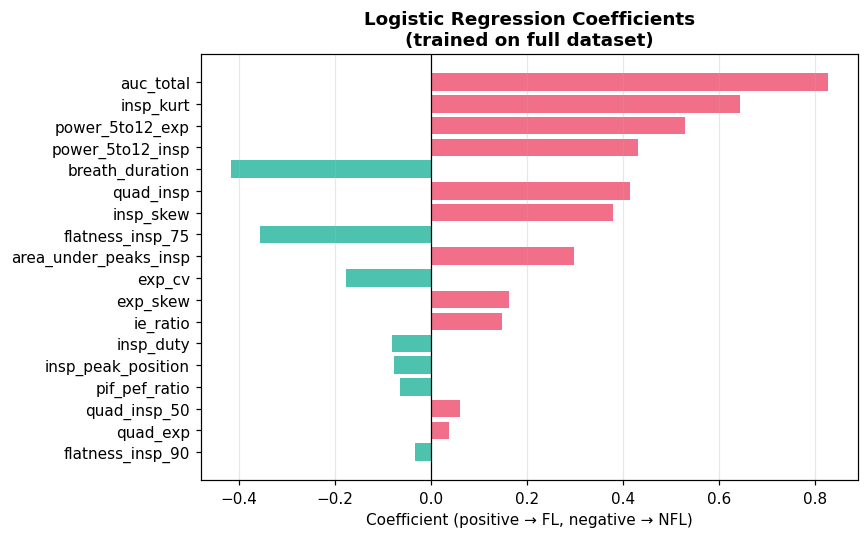

Saved: logreg_coefficients.png


In [48]:
# ── Coefficient plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#ef5675' if v > 0 else '#2eb8a0' for v in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Coefficient (positive → FL, negative → NFL)')
ax.set_title('Logistic Regression Coefficients\n(trained on full dataset)',
             fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'logreg_coefficients.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved: logreg_coefficients.png')

---
## Stage 2 — Comparison Models with LOPO-CV

Random Forest, XGBoost, and LightGBM evaluated under the identical LOPO-CV
protocol. Hyperparameters are intentionally conservative defaults — no tuning
inside the CV loop to avoid leakage.

In [49]:
# ── Model registry ────────────────────────────────────────────────────────────
# Each entry: (name, factory, scale)
# Trees don't strictly need scaling but including it keeps evaluation consistent.
# If you want raw tree behaviour, set scale=False — results should be similar.

n_fl_total  = int((df['target'] == 1).sum())
n_nfl_total = int((df['target'] == 0).sum())
scale_pos   = n_nfl_total / n_fl_total   # for XGBoost class imbalance

MODEL_REGISTRY = [
    (
        'RandomForest',
        lambda: RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            min_samples_leaf=5,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
        ),
        False,   # trees don't require scaling
    ),
    (
        'XGBoost',
        lambda: xgb.XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos,
            eval_metric='logloss',
            use_label_encoder=False,
            random_state=42,
            verbosity=0,
        ),
        False,
    ),
    (
        'LightGBM',
        lambda: lgb.LGBMClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight='balanced',
            random_state=42,
            verbose=-1,
        ),
        False,
    ),
]

print(f'Models to evaluate: {[m[0] for m in MODEL_REGISTRY]}')
print(f'scale_pos_weight for XGBoost: {scale_pos:.2f}')

Models to evaluate: ['RandomForest', 'XGBoost', 'LightGBM']
scale_pos_weight for XGBoost: 0.93


In [50]:
# ── Run LOPO-CV for all comparison models ────────────────────────────────────
all_results   = [lr_results]    # LogReg already done — prepend
all_trues_map = {'LogReg': (lr_trues, lr_probas, lr_preds)}

for model_name, factory, scale in MODEL_REGISTRY:
    print(f'\nRunning {model_name} LOPO-CV...')
    res, trues, probas, preds = lopo_cv(
        df, FEATURE_NAMES, factory, model_name=model_name, scale=scale
    )
    all_results.append(res)
    all_trues_map[model_name] = (trues, probas, preds)
    summarise_lopo(res, model_name)

# Combine into single results dataframe
cv_results_df = pd.concat(all_results, ignore_index=True)
cv_results_df.to_csv(OUT_DIR / 'lopo_cv_results.csv', index=False)
print('\nSaved: lopo_cv_results.csv')


Running RandomForest LOPO-CV...
  [RandomForest] fold 10/84 done
  [RandomForest] fold 20/84 done
  [RandomForest] fold 30/84 done
  [RandomForest] fold 40/84 done
  [RandomForest] fold 50/84 done
  [RandomForest] fold 60/84 done
  [RandomForest] fold 70/84 done
  [RandomForest] fold 80/84 done
  [RandomForest] fold 84/84 done

── RandomForest LOPO-CV Summary ──
  accuracy    : 0.7671 ± 0.1284
  f1          : 0.7527 ± 0.1625
  roc_auc     : 0.8899 ± 0.0782
  kappa       : 0.5164 ± 0.2143

Running XGBoost LOPO-CV...
  [XGBoost] fold 10/84 done
  [XGBoost] fold 20/84 done
  [XGBoost] fold 30/84 done
  [XGBoost] fold 40/84 done
  [XGBoost] fold 50/84 done
  [XGBoost] fold 60/84 done
  [XGBoost] fold 70/84 done
  [XGBoost] fold 80/84 done
  [XGBoost] fold 84/84 done

── XGBoost LOPO-CV Summary ──
  accuracy    : 0.7738 ± 0.1256
  f1          : 0.7650 ± 0.1527
  roc_auc     : 0.8852 ± 0.0832
  kappa       : 0.5259 ± 0.2155

Running LightGBM LOPO-CV...
  [LightGBM] fold 10/84 done
  [LightG

## 4. Results Summary

In [51]:
# ── Aggregated mean ± std across patients, per model ─────────────────────────
metrics = ['accuracy', 'f1', 'roc_auc', 'kappa']
summary_rows = []

for model_name in cv_results_df['model'].unique():
    sub = cv_results_df[cv_results_df['model'] == model_name]
    row = {'model': model_name}
    for m in metrics:
        col = sub[m].dropna()
        row[f'{m}_mean'] = col.mean()
        row[f'{m}_std']  = col.std()
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values('roc_auc_mean', ascending=False)

print('=== LOPO-CV Summary: mean ± std across patients ===')
print(f'{"Model":<15}', end='')
for m in metrics:
    print(f'  {m:<20}', end='')
print()
print('-' * (15 + 22 * len(metrics)))
for _, row in summary_df.iterrows():
    print(f'{row["model"]:<15}', end='')
    for m in metrics:
        print(f'  {row[f"{m}_mean"]:.4f} ± {row[f"{m}_std"]:.4f}  ', end='')
    print()

=== LOPO-CV Summary: mean ± std across patients ===
Model            accuracy              f1                    roc_auc               kappa               
-------------------------------------------------------------------------------------------------------
RandomForest     0.7671 ± 0.1284    0.7527 ± 0.1625    0.8899 ± 0.0782    0.5164 ± 0.2143  
LogReg           0.7602 ± 0.1294    0.7434 ± 0.1618    0.8863 ± 0.0876    0.5033 ± 0.2119  
XGBoost          0.7738 ± 0.1256    0.7650 ± 0.1527    0.8852 ± 0.0832    0.5259 ± 0.2155  
LightGBM         0.7705 ± 0.1239    0.7621 ± 0.1498    0.8834 ± 0.0830    0.5197 ± 0.2127  


In [52]:
# ── Statistical note on variance ─────────────────────────────────────────────
# High std in LOPO-CV is expected: each fold is a different patient with
# different FL burden and severity. The mean is the primary comparison;
# std tells you how consistently the model generalises across patients.

print('=== Per-patient Kappa distribution ===')
for model_name in cv_results_df['model'].unique():
    sub = cv_results_df[cv_results_df['model'] == model_name]['kappa'].dropna()
    q25, q75 = sub.quantile(0.25), sub.quantile(0.75)
    below_chance = (sub < 0).sum()
    print(f'  {model_name:<15}: median={sub.median():.3f}  IQR=[{q25:.3f}, {q75:.3f}]  '
          f'folds_below_chance={below_chance}/{len(sub)}')

=== Per-patient Kappa distribution ===
  LogReg         : median=0.500  IQR=[0.349, 0.664]  folds_below_chance=0/84
  RandomForest   : median=0.525  IQR=[0.350, 0.659]  folds_below_chance=0/84
  XGBoost        : median=0.527  IQR=[0.381, 0.687]  folds_below_chance=0/84
  LightGBM       : median=0.542  IQR=[0.367, 0.677]  folds_below_chance=0/84


## 5. Visualisation

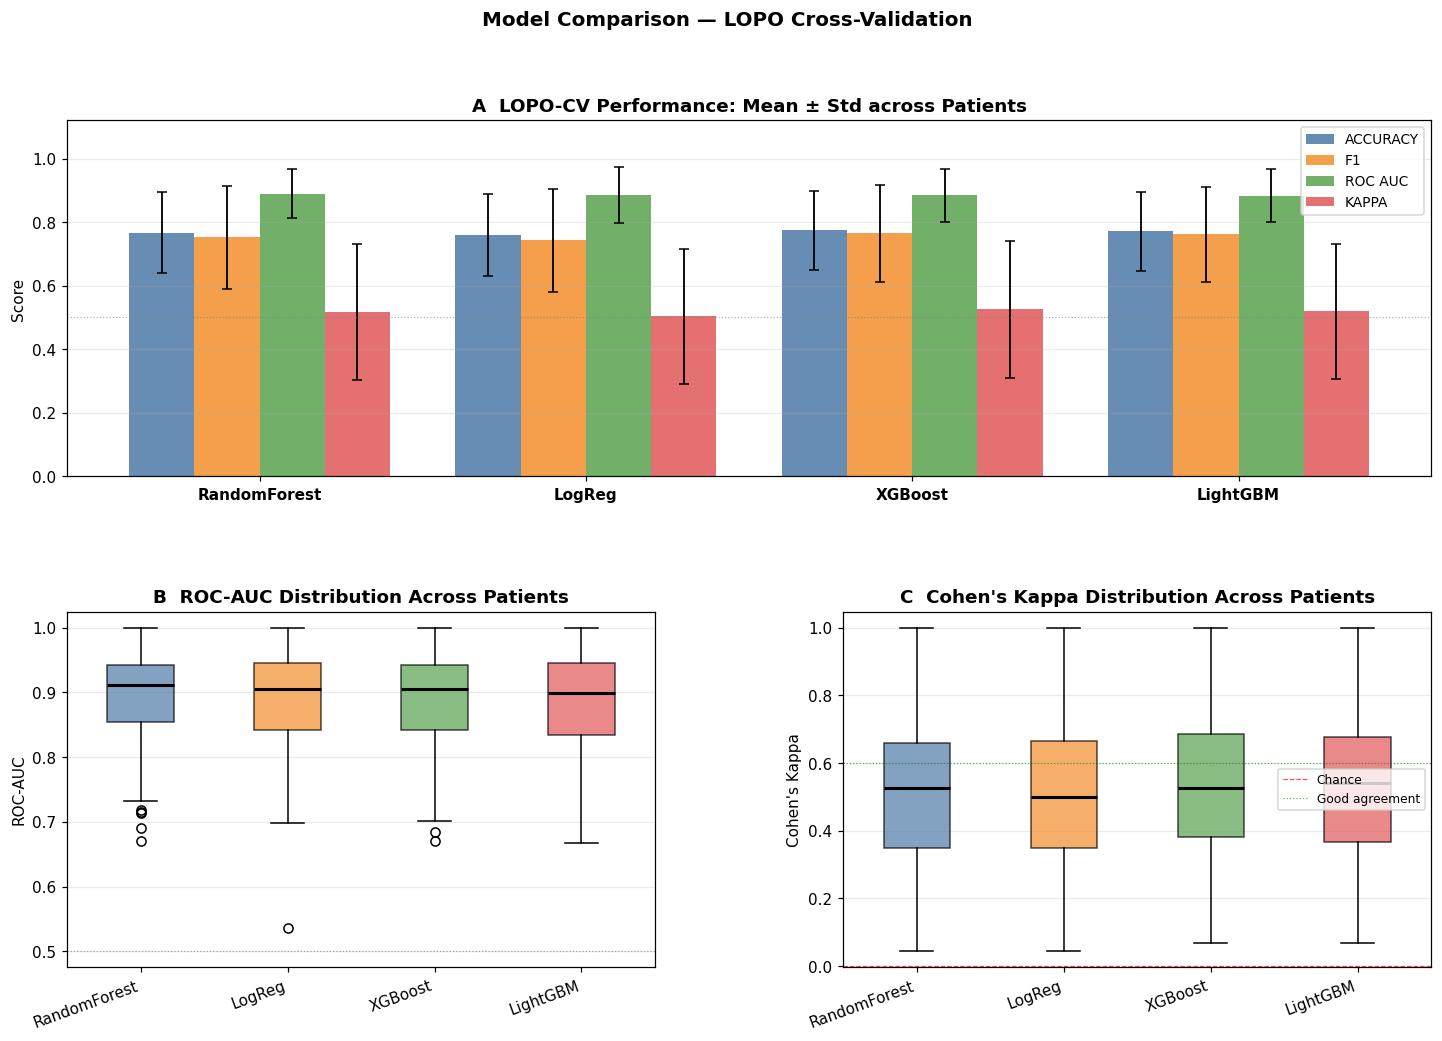

Saved: model_comparison.png


In [53]:
# ── Figure: model comparison ──────────────────────────────────────────────────
model_names = summary_df['model'].tolist()
n_models    = len(model_names)
colors      = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759',
                '#76b7b2', '#edc948', '#b07aa1'][:n_models]

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# ── A: Metric bars (mean ± std) ───────────────────────────────────────────────
ax_bar = fig.add_subplot(gs[0, :])
x = np.arange(n_models)
width = 0.2
offsets = np.linspace(-(len(metrics)-1)/2 * width, (len(metrics)-1)/2 * width, len(metrics))
bar_colors = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']

for i, m in enumerate(metrics):
    means = [summary_df[summary_df['model']==mn][f'{m}_mean'].values[0] for mn in model_names]
    stds  = [summary_df[summary_df['model']==mn][f'{m}_std'].values[0]  for mn in model_names]
    bars  = ax_bar.bar(x + offsets[i], means, width, label=m.upper().replace('_',' '),
                       color=bar_colors[i], alpha=0.85, yerr=stds, capsize=3,
                       error_kw={'elinewidth': 1.2})

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(model_names, fontweight='bold')
ax_bar.set_ylim(0, 1.12)
ax_bar.set_ylabel('Score')
ax_bar.set_title('A  LOPO-CV Performance: Mean ± Std across Patients',
                  fontweight='bold')
ax_bar.legend(loc='upper right', fontsize=9)
ax_bar.axhline(0.5, color='grey', lw=0.8, ls=':', alpha=0.6)
ax_bar.grid(axis='y', alpha=0.25)

# ── B: ROC-AUC distribution per model (box per patient) ───────────────────────
ax_box = fig.add_subplot(gs[1, 0])
roc_data  = [cv_results_df[cv_results_df['model']==mn]['roc_auc'].dropna().values
              for mn in model_names]
bp = ax_box.boxplot(roc_data, labels=model_names, patch_artist=True, notch=False,
                    medianprops={'color': 'black', 'linewidth': 2})
for patch, col in zip(bp['boxes'], colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
ax_box.axhline(0.5, color='grey', lw=0.8, ls=':', alpha=0.7)
ax_box.set_ylabel('ROC-AUC')
ax_box.set_title('B  ROC-AUC Distribution Across Patients', fontweight='bold')
ax_box.set_xticklabels(model_names, rotation=20, ha='right')
ax_box.grid(axis='y', alpha=0.25)

# ── C: Kappa distribution per model ───────────────────────────────────────────
ax_kap = fig.add_subplot(gs[1, 1])
kap_data = [cv_results_df[cv_results_df['model']==mn]['kappa'].dropna().values
             for mn in model_names]
bp2 = ax_kap.boxplot(kap_data, labels=model_names, patch_artist=True, notch=False,
                     medianprops={'color': 'black', 'linewidth': 2})
for patch, col in zip(bp2['boxes'], colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
ax_kap.axhline(0, color='red', lw=0.8, ls='--', alpha=0.7, label='Chance')
ax_kap.axhline(0.6, color='green', lw=0.8, ls=':', alpha=0.6, label='Good agreement')
ax_kap.set_ylabel("Cohen's Kappa")
ax_kap.set_title("C  Cohen's Kappa Distribution Across Patients", fontweight='bold')
ax_kap.set_xticklabels(model_names, rotation=20, ha='right')
ax_kap.legend(fontsize=8)
ax_kap.grid(axis='y', alpha=0.25)

plt.suptitle('Model Comparison — LOPO Cross-Validation', fontsize=13, fontweight='bold')
plt.savefig(OUT_DIR / 'model_comparison.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

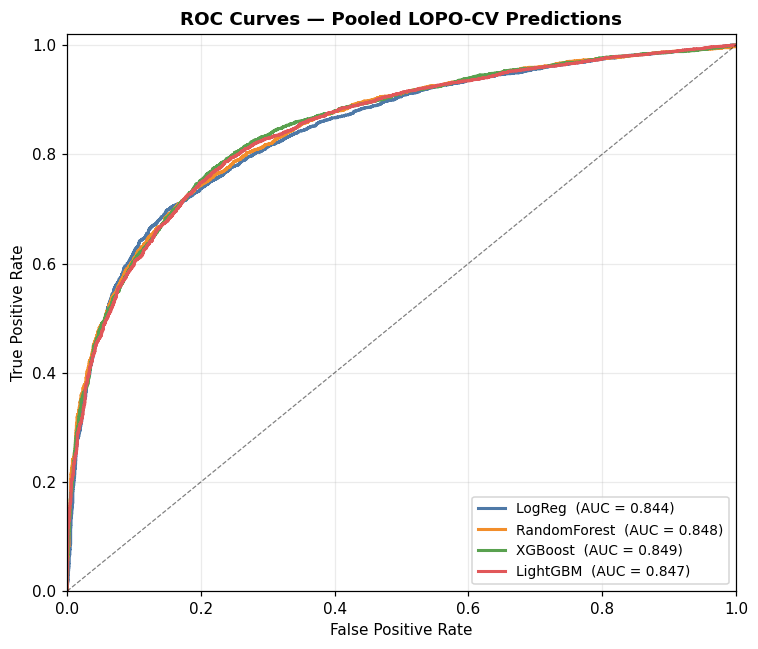

Saved: roc_curves.png


In [54]:
# ── ROC curves (aggregate pooled probabilities across all LOPO folds) ─────────
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(7, 6))

all_model_names = ['LogReg'] + [m[0] for m in MODEL_REGISTRY]
line_colors     = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']

for model_name, col in zip(all_model_names, line_colors):
    trues, probas, _ = all_trues_map[model_name]
    fpr, tpr, _      = roc_curve(trues, probas)
    roc_auc          = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=col,
            label=f'{model_name}  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Pooled LOPO-CV Predictions', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / 'roc_curves.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved: roc_curves.png')

Best model by mean ROC-AUC: RandomForest


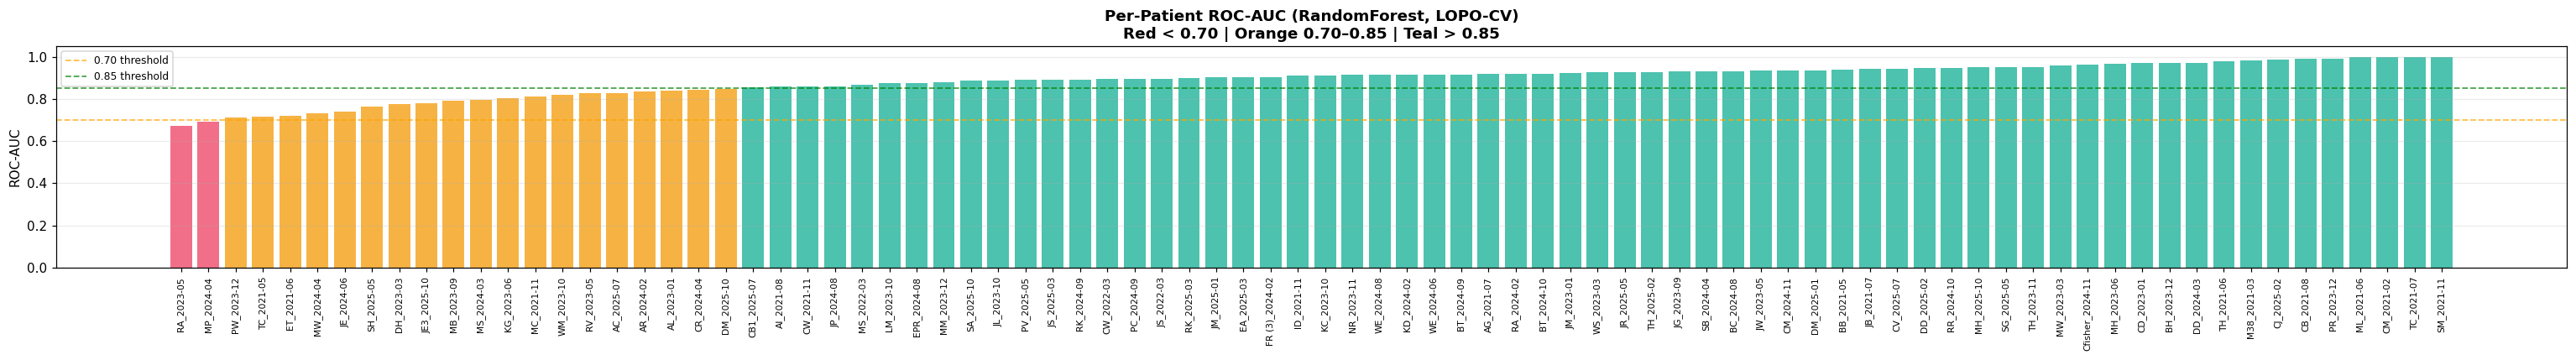

Saved: per_patient_roc.png


In [55]:
# ── Per-patient ROC-AUC: which patients are hardest? ─────────────────────────
# Use LightGBM (typically best) or the best model from summary_df

best_model_name = summary_df.iloc[0]['model']
print(f'Best model by mean ROC-AUC: {best_model_name}')

best_cv = cv_results_df[cv_results_df['model'] == best_model_name].copy()
best_cv = best_cv.sort_values('roc_auc')

fig, ax = plt.subplots(figsize=(max(8, n_patients // 3), 4))
bar_colors = ['#ef5675' if v < 0.70 else '#f5a623' if v < 0.85 else '#2eb8a0'
              for v in best_cv['roc_auc']]
ax.bar(range(len(best_cv)), best_cv['roc_auc'], color=bar_colors, alpha=0.85)
ax.axhline(0.70, color='orange', lw=1.2, ls='--', alpha=0.7, label='0.70 threshold')
ax.axhline(0.85, color='green',  lw=1.2, ls='--', alpha=0.7, label='0.85 threshold')
ax.set_xticks(range(len(best_cv)))
ax.set_xticklabels(best_cv['patient'], rotation=90, fontsize=7)
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0, 1.05)
ax.set_title(f'Per-Patient ROC-AUC ({best_model_name}, LOPO-CV)\n'
              'Red < 0.70 | Orange 0.70–0.85 | Teal > 0.85', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / 'per_patient_roc.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved: per_patient_roc.png')

## 6. Save Best Model

If the best comparison model clearly outperforms LogReg (ROC-AUC ≥ 0.02 higher),
save it as `model_best.pkl`. Otherwise the LogReg baseline is the recommended deploy model.

For the **HITL interface and SHAP analysis** (notebook 03), LightGBM is used
regardless of rank — SHAP TreeExplainer is exact and fast for tree models.

In [56]:
# ── Decision: is the best tree model meaningfully better than LogReg? ────────
lr_auc   = summary_df[summary_df['model'] == 'LogReg']['roc_auc_mean'].values[0]
best_auc = summary_df.iloc[0]['roc_auc_mean']
delta    = best_auc - lr_auc

print(f'LogReg baseline ROC-AUC  : {lr_auc:.4f}')
print(f'Best model ({best_model_name}) ROC-AUC: {best_auc:.4f}')
print(f'Difference               : {delta:+.4f}')

if delta >= 0.02:
    print(f'\n→ {best_model_name} meaningfully outperforms LogReg. Saving as model_best.pkl.')
    recommend = best_model_name
else:
    print(f'\n→ Difference < 0.02. LogReg baseline is recommended for deployment (interpretability + performance).')
    recommend = 'LogReg'

print(f'\nRecommended deploy model: {recommend}')

LogReg baseline ROC-AUC  : 0.8863
Best model (RandomForest) ROC-AUC: 0.8899
Difference               : +0.0036

→ Difference < 0.02. LogReg baseline is recommended for deployment (interpretability + performance).

Recommended deploy model: LogReg


In [57]:
# ── Train and save the best tree model on all data (for SHAP in notebook 03) ─
# Always train LightGBM on full data regardless — it's needed for SHAP XAI.

print('Training LightGBM on full dataset (for SHAP in notebook 03)...')

X_all = df[FEATURE_NAMES].values
y_all = df['target'].values

final_lgbm = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    verbose=-1,
)
final_lgbm.fit(X_all, y_all)

joblib.dump(final_lgbm, OUT_DIR / 'model_lightgbm_full.pkl')
print('Saved: model_lightgbm_full.pkl  (used by notebook 03 for SHAP)')

# Also save best if it differs from LightGBM
if best_model_name not in ('LogReg', 'LightGBM') and delta >= 0.02:
    name_map = {'RandomForest': RandomForestClassifier, 'XGBoost': xgb.XGBClassifier}
    _, best_factory, best_scale = next(
        (n, f, s) for n, f, s in MODEL_REGISTRY if n == best_model_name
    )
    Xb = StandardScaler().fit_transform(X_all) if best_scale else X_all
    final_best = best_factory()
    final_best.fit(Xb, y_all)
    joblib.dump(final_best, OUT_DIR / 'model_best.pkl')
    print(f'Saved: model_best.pkl  ({best_model_name})')

print('\n=== Training complete ===')
print('Saved files:')
for f in ['model_logreg_baseline.pkl', 'scaler_logreg.pkl',
          'model_lightgbm_full.pkl', 'lopo_cv_results.csv',
          'model_comparison.png', 'roc_curves.png',
          'logreg_coefficients.png', 'per_patient_roc.png']:
    p = OUT_DIR / f
    status = '✓' if p.exists() else '—'
    print(f'  {status}  {f}')

Training LightGBM on full dataset (for SHAP in notebook 03)...
Saved: model_lightgbm_full.pkl  (used by notebook 03 for SHAP)

=== Training complete ===
Saved files:
  ✓  model_logreg_baseline.pkl
  ✓  scaler_logreg.pkl
  ✓  model_lightgbm_full.pkl
  ✓  lopo_cv_results.csv
  ✓  model_comparison.png
  ✓  roc_curves.png
  ✓  logreg_coefficients.png
  ✓  per_patient_roc.png


---
## Notes for Notebook 03 (XAI)

Load these files:
```python
import joblib, pandas as pd
lgbm_model   = joblib.load('model_lightgbm_full.pkl')
lr_model     = joblib.load('model_logreg_baseline.pkl')
scaler_lr    = joblib.load('scaler_logreg.pkl')
features_df  = pd.read_csv('features_clean.csv')
lopo_results = pd.read_csv('lopo_cv_results.csv')
```

SHAP should use `model_lightgbm_full.pkl` with `shap.TreeExplainer` —
exact values, no sampling required, fast on this feature dimensionality.

Per-patient LOPO fold predictions are in `lopo_cv_results.csv` and can be
used to identify which patients to prioritise for error analysis.